In [1]:
import sys
import os

import matplotlib.pyplot as plt

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from my_nn import (
    MLP,
    accuracy,
    load_mnist,
    train_epoch_sgd,
    build_optimizer_state,
)

In [2]:
x_train, y_train, x_test, y_test = load_mnist()

In [6]:
def train_model(hidden_dims, epochs):
    model = MLP(
        input_dim=784,
        hidden_dims=hidden_dims,
        num_classes=10,
        init_method="normal_small",
        dropout_p=0.0,
        seed=42,
    )

    train_losses = []
    train_accs = []
    test_accs = []
    opt_state = build_optimizer_state(model, "sgd")

    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch_sgd(
            model,
            x_train,
            y_train,
            batch_size=64,
            lr=0.3,
            l2_lambda=0.0,
            optimizer="sgd",
            opt_state=opt_state,
        )
        logits_te = model.forward(x_test, train=False)
        te_acc = accuracy(logits_te, y_test)
        train_losses.append(tl)
        train_accs.append(ta)
        test_accs.append(te_acc)
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"epoch {epoch:3d}  train_loss={tl:.4f}  train_acc={ta:.4f}  test_acc={te_acc:.4f}"
            )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, epochs + 1), train_losses, label="train loss", color="C0")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax2 = ax.twinx()
    ax2.plot(
        range(1, epochs + 1), train_accs, label="train acc", color="C1", linestyle="--"
    )
    ax2.plot(range(1, epochs + 1), test_accs, label="test acc", color="C2")
    ax2.set_ylabel("accuracy")
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [ln.get_label() for ln in lines], loc="center right")
    ax.set_title("train process")
    fig.tight_layout()
    fig.savefig("./curve.png", dpi=150)

epoch   1  train_loss=0.3524  train_acc=0.9452  test_acc=0.9434
epoch   5  train_loss=0.0629  train_acc=0.9817  test_acc=0.9712
epoch  10  train_loss=0.0256  train_acc=0.9907  test_acc=0.9748
epoch  15  train_loss=0.0116  train_acc=0.9938  test_acc=0.9750
epoch  20  train_loss=0.0056  train_acc=0.9973  test_acc=0.9770
epoch  25  train_loss=0.0032  train_acc=0.9988  test_acc=0.9782
epoch  30  train_loss=0.0021  train_acc=0.9996  test_acc=0.9786
epoch  35  train_loss=0.0016  train_acc=0.9998  test_acc=0.9788
epoch  40  train_loss=0.0012  train_acc=0.9999  test_acc=0.9791


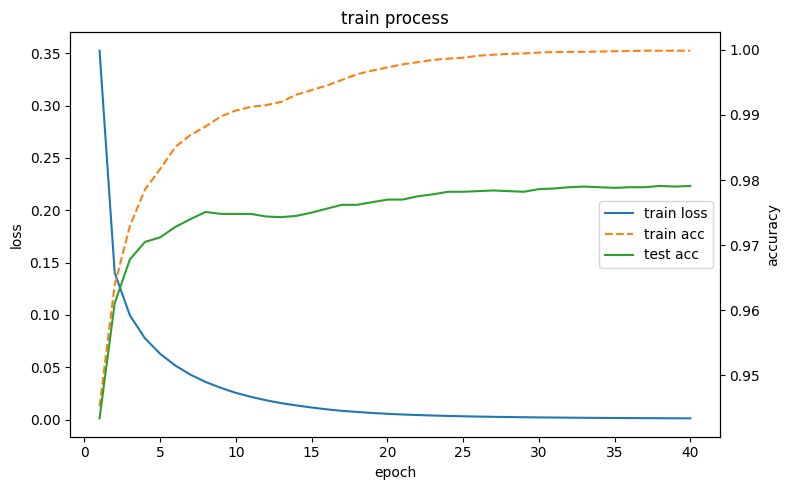

In [7]:
# 删除一个隐藏层
train_model([96], 40)

epoch   1  train_loss=2.3023  train_acc=0.1044  test_acc=0.1028
epoch   5  train_loss=0.1175  train_acc=0.9689  test_acc=0.9638
epoch  10  train_loss=0.0471  train_acc=0.9823  test_acc=0.9692
epoch  15  train_loss=0.0294  train_acc=0.9831  test_acc=0.9674
epoch  20  train_loss=0.0230  train_acc=0.9847  test_acc=0.9677
epoch  25  train_loss=0.0181  train_acc=0.9917  test_acc=0.9733
epoch  30  train_loss=0.0127  train_acc=0.9957  test_acc=0.9769
epoch  35  train_loss=0.0132  train_acc=0.9883  test_acc=0.9682
epoch  40  train_loss=0.0094  train_acc=0.9979  test_acc=0.9751


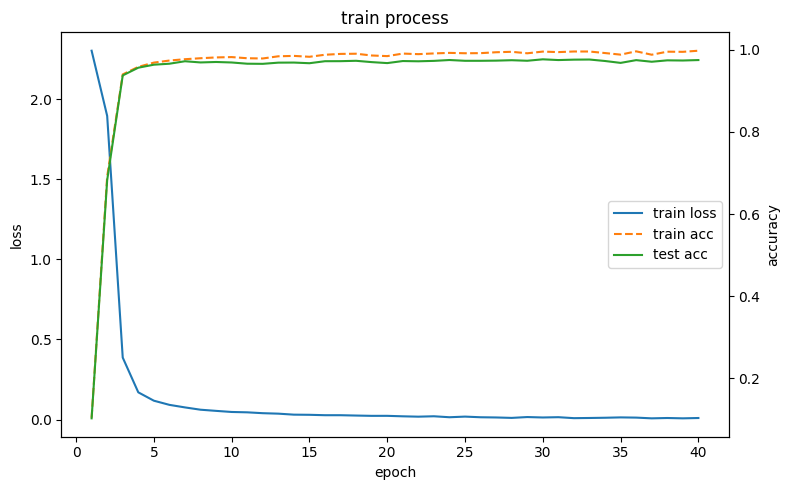

In [9]:
# 增加一个隐藏层
train_model([96, 64, 16], 40)